In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_csv("/content/coin_Aave.csv")
df

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Aave,AAVE,2020-10-05 23:59:59,55.112358,49.787900,52.675035,53.219243,0.000000e+00,8.912813e+07
1,2,Aave,AAVE,2020-10-06 23:59:59,53.402270,40.734578,53.291969,42.401599,5.830915e+05,7.101144e+07
2,3,Aave,AAVE,2020-10-07 23:59:59,42.408314,35.970690,42.399947,40.083976,6.828342e+05,6.713004e+07
3,4,Aave,AAVE,2020-10-08 23:59:59,44.902511,36.696057,39.885262,43.764463,1.658817e+06,2.202651e+08
4,5,Aave,AAVE,2020-10-09 23:59:59,47.569533,43.291776,43.764463,46.817744,8.155377e+05,2.356322e+08
...,...,...,...,...,...,...,...,...,...,...
270,271,Aave,AAVE,2021-07-02 23:59:59,234.483957,215.951539,230.814119,233.948437,2.566395e+08,3.001542e+09
271,272,Aave,AAVE,2021-07-03 23:59:59,265.107342,228.485206,234.208478,259.655225,3.853778e+08,3.331546e+09
272,273,Aave,AAVE,2021-07-04 23:59:59,289.001124,248.285491,259.399426,277.038792,4.275719e+08,3.555054e+09
273,274,Aave,AAVE,2021-07-05 23:59:59,317.387234,263.433881,277.110533,307.829079,7.931409e+08,3.950269e+09


In [3]:
print(df.head())

   SNo  Name Symbol                 Date       High        Low       Open  \
0    1  Aave   AAVE  2020-10-05 23:59:59  55.112358  49.787900  52.675035   
1    2  Aave   AAVE  2020-10-06 23:59:59  53.402270  40.734578  53.291969   
2    3  Aave   AAVE  2020-10-07 23:59:59  42.408314  35.970690  42.399947   
3    4  Aave   AAVE  2020-10-08 23:59:59  44.902511  36.696057  39.885262   
4    5  Aave   AAVE  2020-10-09 23:59:59  47.569533  43.291776  43.764463   

       Close        Volume     Marketcap  
0  53.219243  0.000000e+00  8.912813e+07  
1  42.401599  5.830915e+05  7.101144e+07  
2  40.083976  6.828342e+05  6.713004e+07  
3  43.764463  1.658817e+06  2.202651e+08  
4  46.817744  8.155377e+05  2.356322e+08  


In [4]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
SNo          0
Name         0
Symbol       0
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Marketcap    0
dtype: int64


In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
print("\nDataset Shape :", df.shape)


Dataset Shape : (275, 10)


In [10]:

le = LabelEncoder()

df["Marketcap"] = le.fit_transform(
    df["Marketcap"]
)

In [11]:

X = df[["Symbol", "Marketcap"]]
y = df["Volume"]

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
X_train.select_dtypes(include=['object']).columns

Index(['Symbol'], dtype='object')

In [19]:
print(X_train.select_dtypes(include='object').columns)
print(X_test.select_dtypes(include='object').columns)

Index(['Symbol'], dtype='object')
Index(['Symbol'], dtype='object')


In [23]:
print("Object columns in X_train:")
print(X_train.select_dtypes(include='object').columns)

print("\nObject columns in X_test:")
print(X_test.select_dtypes(include='object').columns)

print("\nFirst few rows of X_test:")
print(X_test.head())

Object columns in X_train:
Index(['Symbol'], dtype='object')

Object columns in X_test:
Index(['Symbol'], dtype='object')

First few rows of X_test:
    Symbol  Marketcap
30    AAVE         13
139   AAVE        233
195   AAVE        204
126   AAVE        260
215   AAVE        253


In [25]:
print(X_train.head())

print(X_train.dtypes)

print(X_train.columns)

print(X_train.select_dtypes(include='object').columns)

    Symbol  Marketcap
10    AAVE          4
260   AAVE        114
267   AAVE        121
33    AAVE         33
222   AAVE        270
Symbol       object
Marketcap     int64
dtype: object
Index(['Symbol', 'Marketcap'], dtype='object')
Index(['Symbol'], dtype='object')


In [28]:
def predict_price():
    user_data = pd.DataFrame({...})
    prediction = model.predict(user_data)
    return prediction

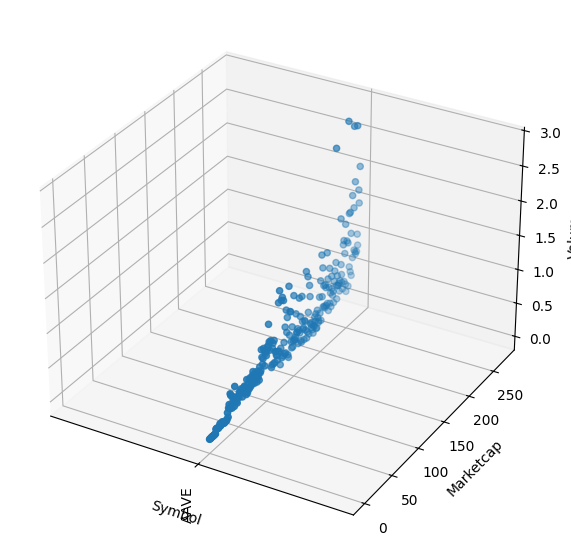

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Symbol_encoded"] = le.fit_transform(df["Symbol"])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Symbol_encoded"],
    df["Marketcap"],
    df["Volume"]
)

ax.set_xticks(df["Symbol_encoded"].unique())
ax.set_xticklabels(le.classes_, rotation=90)

ax.set_xlabel("Symbol")
ax.set_ylabel("Marketcap")
ax.set_zlabel("Volume")

plt.show()